# Poisson Solver Demo: Stratified Random Non-Uniform Grid

This notebook demonstrates solving the 2D Poisson equation on a disk domain $D = \{(r, \theta) : 0 \le r \le R\}$ on a **Stratified Random Non-Uniform Angular Mesh** using fast **NUFFT-accelerated** conjugate gradient solvers:

$$\Delta u = f(r, \theta) \quad \text{in } D$$
$$u(R, \theta) = g(\theta) \quad \text{on } \partial D \quad \text{(Dirichlet)}$$

### Problem & Parameter Configuration:
- **Domain Radius**: $R = 1.0$
- **Grid Dimensions**: $N = 64$ (angular points), $M = 64$ (radial points)
- **Angular Mesh**: Stratified random distribution (places one independent random angle per sector $[2\pi j/N, 2\pi (j+1)/N)$)
- **Analytical Solution**: $u(x, y) = 3 e^{x+y} (x - x^2)(y - y^2) + 5$
- **RHS Forcing Function**: $\Delta u = 6 e^{x+y} x y (-3 + x + y + x y)$
- **Angular Solver Strategy**: `grid_type = 3` (Unsquared PCGLS with Pipe & Menon density compensation)
- **Regularization Parameter**: `reg_param = 1e-12`
- **Solver Tolerance & Max Iterations**: `tol_nufft = 1e-10`, `maxiter_nufft = 200`
- **FINUFFT Kernel Tolerance**: `eps_finufft = 1e-12`
- **Backend Selection**: Configurable CPU (`USE_GPU = False`) or GPU (`USE_GPU = True`)

In [1]:
import os
import sys

# ---------------------------------------------------------
# Backend & Environment Configuration
# ---------------------------------------------------------
USE_GPU = False  # Set to True for NVIDIA GPU (CuPy/cuFINUFFT), False for CPU (FINUFFT)

# Auto-detect Google Colab environment
IN_COLAB = "google.colab" in sys.modules or os.environ.get("COLAB_GPU") is not None

if IN_COLAB:
    if not os.path.exists("Poisson_Solver"):
        os.system("git clone https://github.com/CharliePyle4/NUFFTRR_Poisson.git")
        if os.path.exists("NUFFTRR_Poisson"):
            os.chdir("NUFFTRR_Poisson")
    os.system("pip install -r requirements.txt -q")
    if USE_GPU:
        os.system("pip install cufinufft -q")

import numpy as np
import matplotlib.pyplot as plt

from Poisson_Solver.grids import (
    generate_uniform_radial,
    generate_stratified_rand_azimuthal,
    generate_cartesian_grid_on_disk,
    plot_grid,
    compute_zero_mode
)
from Poisson_Solver.visualization import (
    plot_on_disk_with_error,
    compute_error_metrics
)
from Poisson_Solver.poisson_solver import poisson_solver

backend_name = "GPU (NVIDIA CuPy / cuFINUFFT)" if USE_GPU else "CPU (Multithreaded FINUFFT)"
print("=" * 60)
print(f"  Executing Non-Uniform Poisson Solver on: {backend_name}")
print("=" * 60)

  Executing Non-Uniform Poisson Solver on: CPU (Multithreaded FINUFFT)


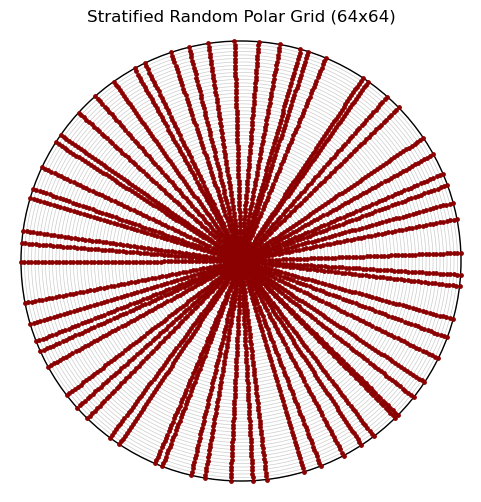

In [2]:
# 1. Define problem domain and stratified random polar discretization
np.random.seed(42)  # For reproducible stratified sampling

R = 1.0
N = 64  # Number of angular points
M = 64  # Number of radial points

# Generate radial grid and stratified random angular grid
r_m = generate_uniform_radial(M, R)
theta_j = generate_stratified_rand_azimuthal(N)
x_coord, y_coord = generate_cartesian_grid_on_disk(theta_j, r_m)

# Visualize the stratified random polar grid
fig, ax = plt.subplots(figsize=(6, 6))
plot_grid(ax, theta_j, r_m, R, title=f"Stratified Random Polar Grid ({N}x{M})", color="darkred")
plt.show()

In [3]:
# 2. Define problem functions
def u_exact(x, y):
    return 3 * np.exp(x + y) * (x - x**2) * (y - y**2) + 5

def f_rhs(x, y):
    return 6 * np.exp(x + y) * x * y * (-3 + x + y + x * y)

# Evaluate exact solution and forcing on the stratified random grid
u_true = u_exact(x_coord, y_coord)
f_values = f_rhs(x_coord, y_coord)
g_values = u_true[:, -1]  # Dirichlet boundary data at outer radius r = R

# Compute zero mode using spectral NUFFT analysis
u_0 = compute_zero_mode(u_true, theta_j, azu_unif=1)

In [4]:
# 3. Execute the Non-Uniform Poisson Solver (Unsquared PCGLS)
u_approx = poisson_solver(
    f_values=f_values,
    g_values=g_values,
    u_fourier_0=u_0,
    N=N,
    M=M,
    r_m=r_m,
    theta_j=theta_j,
    R=R,
    quad_rule=1,            # 1: Trapezoidal, 2: Simpson
    BC_choice=1,            # 1: Dirichlet, 2: Neumann
    rad_unif=1,             # 1: Uniform radial grid
    grid_type=3,            # 3: Unsquared PCGLS, 2: Block-CG
    maxiter_nufft=200,      # Maximum PCGLS iterations
    tol_nufft=1e-10,        # PCGLS convergence tolerance
    reg_param=1e-12,        # Regularization parameter
    eps_finufft=1e-12,      # Target FINUFFT precision
    precond_shift=1e-3,     # Preconditioner spectral shift
    kde_oversample=4,       # KDE oversampling factor
    kde_bandwidth=1.0,      # KDE bandwidth multiplier
    num_processors=None,    # Auto-detect available cores
    use_gpu=USE_GPU
)

In [5]:
# 4. Calculate and print error metrics
linf, linf_rel, l2, l2_rel = compute_error_metrics(u_approx, u_true, r_m, theta_j)

print("=" * 60)
print(f"  Poisson Solver Results (Stratified Random Grid on {backend_name})")
print("=" * 60)
print(f"  Max Error (L_inf):       {linf:.4e}")
print(f"  Relative L_inf Error:    {linf_rel:.4e}")
print(f"  L2 Error:                {l2:.4e}")
print(f"  Relative L2 Error:       {l2_rel:.4e}")
print("=" * 60)

  Poisson Solver Results (Stratified Random Grid on CPU (Multithreaded FINUFFT))
  Max Error (L_inf):       2.7573e-05
  Relative L_inf Error:    4.5482e-06
  L2 Error:                2.3656e-05
  Relative L2 Error:       2.6604e-06


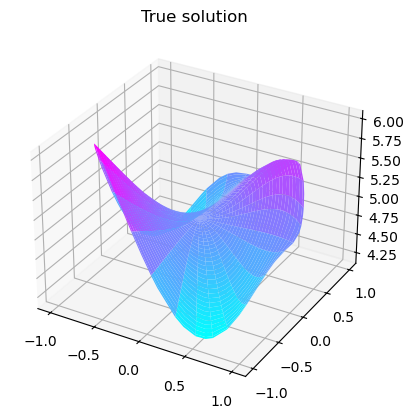

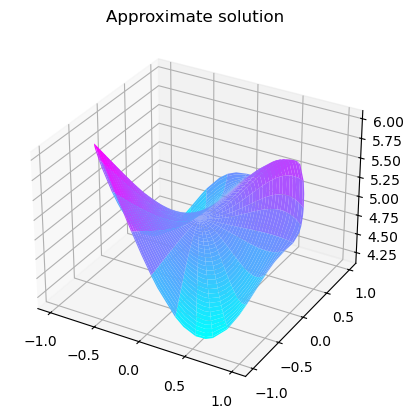

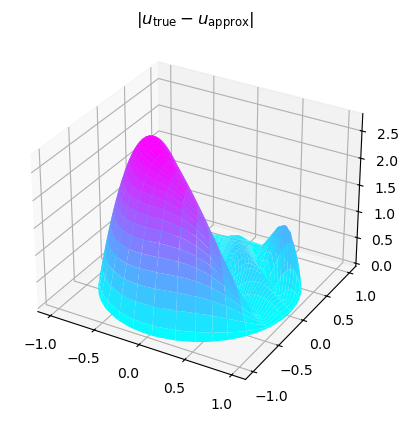

In [6]:
# 5. Plot True Solution, Approximate Solution, and Pointwise Error
plot_on_disk_with_error(x_coord, y_coord, u_approx, u_true)